# Combined portfolio — MES + M2K + M6A, one contract each, one $50k Tradovate account

**Hand-picked, not the algorithmic 20-combination winner.** An earlier version of
this notebook brute-forced all C(6,3)=20 three-instrument combinations and picked by
combined Sharpe alone -- the winner was MNQ+6J+M6A, but `monte_carlo.ipynb` showed
that combo's real-history result (Sharpe 2.34, no breach) was a **lucky draw**: a
5x-leveraged stress test against 100 resampled histories gave a 60% breach rate. On
inspection, 6J had **no standalone edge at all** (every indicator family showed a
negative `trade_sharpe_lb` in its own `step_1`) and had even breached the drawdown
limit *on its own* once leverage made it tradeable -- it only made the automated
selection because of its low/negative correlation with the other two, not because it
was a good strategy by itself. Relying on correlation alone to justify including a
demonstrably weak, single-instrument-breaching strategy is exactly the kind of thing
that looks good in one backtest window and blows up in the next.

**This version hand-picks the 3 instruments whose *own* standalone step_1/step_2
results were genuinely good**:

| Instrument | Winning pair | Solo Sharpe | Solo Calmar |
|---|---|---|---|
| MES | KAMA(26)/SMA(42) | 1.62 | 2.94 |
| M2K | EMA(2)/SMA(12) | 1.61 | 2.91 |
| M6A | KAMA(58)/SMA(102) | 1.63 | 3.47 |

(MNQ excluded -- underperformed its own buy-and-hold, negative alpha. M6E/6J
excluded -- no standalone edge in either, per their own step_1's honest verdict.)

**Sizing: genuinely ~1 contract of each, not a percent-of-equity split.** Each
instrument's `WeightedStrategy.weight` is set so that, at `leverage=2`, its target
notional stays pinned to roughly 1 contract across the *entire* price range this
instrument actually traded at in this window (computed from each instrument's own
real max close + a small buffer, so it doesn't round down to 0 right at the top of
its range) -- verified below via the same exposure/leverage display introduced last
session, rather than assumed. `leverage=2` (not the 5x used in the rejected combo) is
enough to fit all 3 comfortably (~55-65% of equity as margin if all 3 are
simultaneously in a position), without needing anywhere near the aggressive leverage
that made the previous combo's Monte Carlo so sequence-dependent.


In [1]:
import os
from dataclasses import replace

import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, Middleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.mongo_timescale_aggregator import fetch_market_data

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit


In [2]:

SOURCE = "ib"
RESOLUTION = "1_hour"
DATE_FROM = "2019-10-01"
DATE_TO = "2026-06-01"
INTERVAL = 1
UNIT_OF_TIME = "hour"
MAX_LEVERAGE = 2
ACCOUNT_BALANCE = 50_000
# multiplier over each instrument's own observed max price, so its 1-contract sizing
# doesn't round down to 0 right at the top of its historical range (see the weight
# derivation below).
PRICE_HEADROOM = 1.05

SELECTED_SYMBOLS = ["MES", "M2K", "M6A"]

# Each instrument's own winning crossover strategy, from its own step_1.
INSTRUMENT_CONFIGS = {
    "MES": {
        "fast_name": "kama_26",
        "fast_fn": lambda ohlc: Indicators.kama(ohlc, length=26, fast=2, slow=30),
        "slow_name": "sma_42",
        "slow_fn": lambda ohlc: Indicators.sma(ohlc, 42),
    },
    "M2K": {
        "fast_name": "ema_2",
        "fast_fn": lambda ohlc: Indicators.ema(ohlc, length=2),
        "slow_name": "sma_12",
        "slow_fn": lambda ohlc: Indicators.sma(ohlc, 12),
    },
    "M6A": {
        "fast_name": "kama_58",
        "fast_fn": lambda ohlc: Indicators.kama(ohlc, length=58, fast=2, slow=30),
        "slow_name": "sma_102",
        "slow_fn": lambda ohlc: Indicators.sma(ohlc, 102),
    },
}

OHLC = {
    sym: fetch_market_data(source=SOURCE, display_symbol=sym, resolution=RESOLUTION).loc[DATE_FROM:DATE_TO]
    for sym in SELECTED_SYMBOLS
}
for sym, df in OHLC.items():
    print(f"{sym}: {len(df)} bars, {df.index.min()} -> {df.index.max()}, "
          f"price range {df['close'].min():.4f}-{df['close'].max():.4f}")


MES: 5313 bars, 2025-07-08 14:42:16.999000 -> 2026-06-01 23:59:59.999000, price range 6421.2500-7688.5000
M2K: 5313 bars, 2025-07-08 14:47:05.999000 -> 2026-06-01 23:59:59.999000, price range 2219.2000-2965.7000
M6A: 5299 bars, 2025-07-08 14:50:18.999000 -> 2026-06-01 23:59:59.999000, price range 0.6440-0.7252


## Deriving "1 contract" weights

`Rebalancer` sizes each position as
`raw_volume = (balance * percent * leverage) / (price * point_value)`, floored to a
whole contract. Setting `percent_i = (max_price_i * PRICE_HEADROOM * point_value_i) /
(ACCOUNT_BALANCE * MAX_LEVERAGE)` makes `raw_volume` sit at (or just above) exactly 1
even at this instrument's own historical price peak, and correspondingly higher (but
still floors to 1, not 2, as long as `PRICE_HEADROOM` isn't too generous) everywhere
below that peak -- verified numerically right below, not just asserted.


In [3]:

def one_contract_weight(symbol: str) -> float:
    point_value = TRADOVATE_FUTURES[symbol].point_value
    max_price = OHLC[symbol]["close"].max()
    target_notional = max_price * PRICE_HEADROOM * point_value
    return target_notional / (ACCOUNT_BALANCE * MAX_LEVERAGE)


WEIGHTS = {sym: one_contract_weight(sym) for sym in SELECTED_SYMBOLS}
print("Weights:", {k: round(v, 4) for k, v in WEIGHTS.items()})
print(f"Sum of weights (worst-case simultaneous margin use): {sum(WEIGHTS.values()):.1%} of equity")

# Verify raw_volume actually floors to 1 (not 0 or 2) across each instrument's whole
# observed price range, at both leverage-2 sizing and the account balance used below.
for sym in SELECTED_SYMBOLS:
    point_value = TRADOVATE_FUTURES[sym].point_value
    lo, hi = OHLC[sym]["close"].min(), OHLC[sym]["close"].max()
    raw_at_lo = (ACCOUNT_BALANCE * WEIGHTS[sym] * MAX_LEVERAGE) / (lo * point_value)
    raw_at_hi = (ACCOUNT_BALANCE * WEIGHTS[sym] * MAX_LEVERAGE) / (hi * point_value)
    print(f"{sym}: raw_volume ranges {raw_at_hi:.3f} (at max price) -- {raw_at_lo:.3f} (at min price) "
          f"-> floors to {int(raw_at_hi)}-{int(raw_at_lo)} contracts across the whole window")


Weights: {'MES': np.float64(0.4036), 'M2K': np.float64(0.1557), 'M6A': np.float64(0.0761)}
Sum of weights (worst-case simultaneous margin use): 63.5% of equity
MES: raw_volume ranges 1.050 (at max price) -- 1.257 (at min price) -> floors to 1-1 contracts across the whole window
M2K: raw_volume ranges 1.050 (at max price) -- 1.403 (at min price) -> floors to 1-1 contracts across the whole window
M6A: raw_volume ranges 1.050 (at max price) -- 1.182 (at min price) -> floors to 1-1 contracts across the whole window


In [4]:

class ExposureRecorder(Middleware):
    """Records per-symbol contracts/notional and account-level gross notional /
    effective leverage at every tick -- confirms the "1 contract each" sizing target
    actually held throughout the backtest, not just at the two endpoints checked
    above."""

    def __init__(self):
        self.records: list[dict] = []

    def after_tick(self, bt) -> None:
        equity = bt.exchange.get_asset_total_in_usd()
        row = {"time_close": bt.market.current["time_close"], "equity": equity}
        total_notional = 0.0
        for symbol, position in bt.exchange.positions.open_positions.items():
            price = bt.exchange.get_market_price(symbol=symbol)
            point_value = bt.exchange.get_point_value(symbol)
            notional = position.volume * price * point_value
            row[f"{symbol}__contracts"] = position.volume
            row[f"{symbol}__notional"] = notional
            total_notional += notional
        row["total_gross_notional"] = total_notional
        row["effective_leverage"] = total_notional / equity if equity else 0.0
        self.records.append(row)

    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.records).set_index("time_close").fillna(0.0)


def build_combined_backtest(record_exposure: bool = False):
    """Builds and runs the combined MES+M2K+M6A backtest at their 1-contract-each
    weights, leveraged sizing on, real Tradeify drawdown middleware, $50k deposit."""
    market = Market()
    strategies = []

    for sym in SELECTED_SYMBOLS:
        cfg = INSTRUMENT_CONFIGS[sym]
        symbol = f"{sym}/USD"
        ohlc = OHLC[sym]
        market.add_market(symbol=symbol, df=ohlc)
        market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                              indicator_name=cfg["fast_name"], df=cfg["fast_fn"](ohlc))
        market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                              indicator_name=cfg["slow_name"], df=cfg["slow_fn"](ohlc))
        strategies.append(WeightedStrategy(
            weight=WEIGHTS[sym],
            strategy=MaCrossoverStrategy(
                key=f"{cfg['fast_name']}_{cfg['slow_name']}_{sym}", market=market, symbol=symbol,
                direction=StrategyDirection.long,
                fast_indicator_key=cfg["fast_name"], slow_indicator_key=cfg["slow_name"],
                sl_percent=0.3, tp_percent=0.6, sl_enabled=True, tp_enabled=True,
            ),
        ))

    market.compile()
    portfolio = Portfolio(weighted_strategies=strategies, output_scale=1)

    # WEIGHTS is tuned so raw_volume floors to 1 contract at the account's *starting*
    # $50k balance -- but Rebalancer sizes off *current* (compounding) equity, so a
    # good run that grows the account, or a stretch of unusually low prices, could
    # otherwise push a position to 2 contracts without anyone deciding that on
    # purpose. max_position_size=1 is a hard ceiling that catches that case
    # regardless of what the percent-of-equity formula computes -- only overridden
    # for the 3 instruments actually meant to be capped at 1; every other symbol in
    # TRADOVATE_FUTURES is untouched.
    symbols_with_ceiling = {
        **TRADOVATE_FUTURES,
        **{sym: replace(TRADOVATE_FUTURES[sym], max_position_size=1.0) for sym in SELECTED_SYMBOLS},
    }
    symbol_config_provider = TradovateSymbolConfigProvider(
        symbols=symbols_with_ceiling, default_fee_per_contract=0.0
    )
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=MAX_LEVERAGE,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=True,
    )
    # periods_per_year=252: real trading-days/year convention for futures (not 365,
    # which is only correct for a 24/7 crypto market) -- using 365 here previously
    # inflated every Sharpe/Sortino/annualized-volatility number by sqrt(365/252)
    # =~ 1.20 (~20%). CAGR/Calmar/max_drawdown/net_return are unaffected.
    reporter = PerformanceAnalyzer(
        market=market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[f"{sym}/USD" for sym in SELECTED_SYMBOLS],
        periods_per_year=252,
    )
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.04)
    # Tradeify's real $1,250/day soft daily-loss pause on a $50k account (2.5% of
    # balance) -- previously not modeled at all in this pipeline. Placed first so it
    # gets a chance to pause the day before the (permanent) drawdown check runs.
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.025)
    exposure_recorder = ExposureRecorder() if record_exposure else None
    middlewares = [daily_loss_middleware, drawdown_middleware] + (
        [exposure_recorder] if exposure_recorder else []
    )

    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=middlewares)
    backtest.exchange.transactions.add_deposit(asset="USD", volume=ACCOUNT_BALANCE)
    backtest.run_all()

    return backtest, reporter, drawdown_middleware, exposure_recorder


## Run


In [5]:

backtest, reporter, drawdown_middleware, exposure_recorder = build_combined_backtest(record_exposure=True)

print("Candles Processed: ", backtest.market.current["num"])
print("Account failed (drawdown breach): ", drawdown_middleware.account_failed)
print("Drawdown floor locked (reached profit buffer): ", drawdown_middleware.locked)
display(HTML(backtest.reporter.summary_html_table()))


Candles Processed:  5312
Account failed (drawdown breach):  False
Drawdown floor locked (reached profit buffer):  True


metric,algo,MES/USD,M2K/USD,M6A/USD,description
sharpe_ratio,1.6125,1.1979,1.0983,0.9459,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,2.5875,1.7736,1.7024,1.4314,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,6.8318,11.2466,18.0309,7.1794,How much the equity curve swings per year. Lower = smoother.
cagr_percent,16.9020,20.4368,30.1255,9.9259,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,3.7670,2.0631,2.5210,2.1521,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,3.3578,1.8361,2.2342,1.9246,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-4.4869,-9.9056,-11.9498,-4.6122,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,71,72,84,97,How long it took to recover the loss. Shorter is better.
ulcer_index,1.5776,2.3811,3.6747,1.6987,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.5832,-1.0687,-1.7938,-0.7489,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


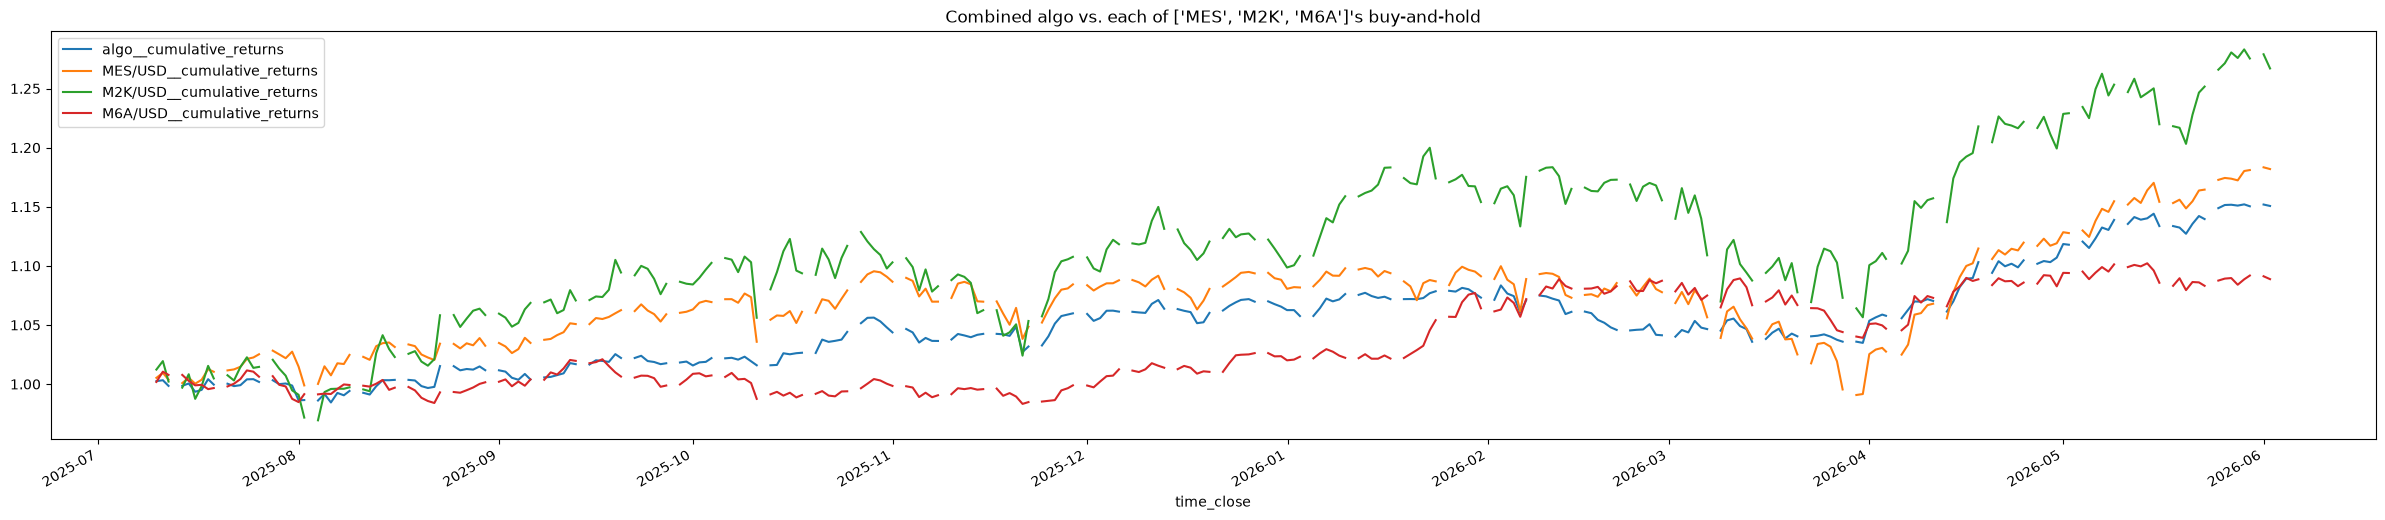

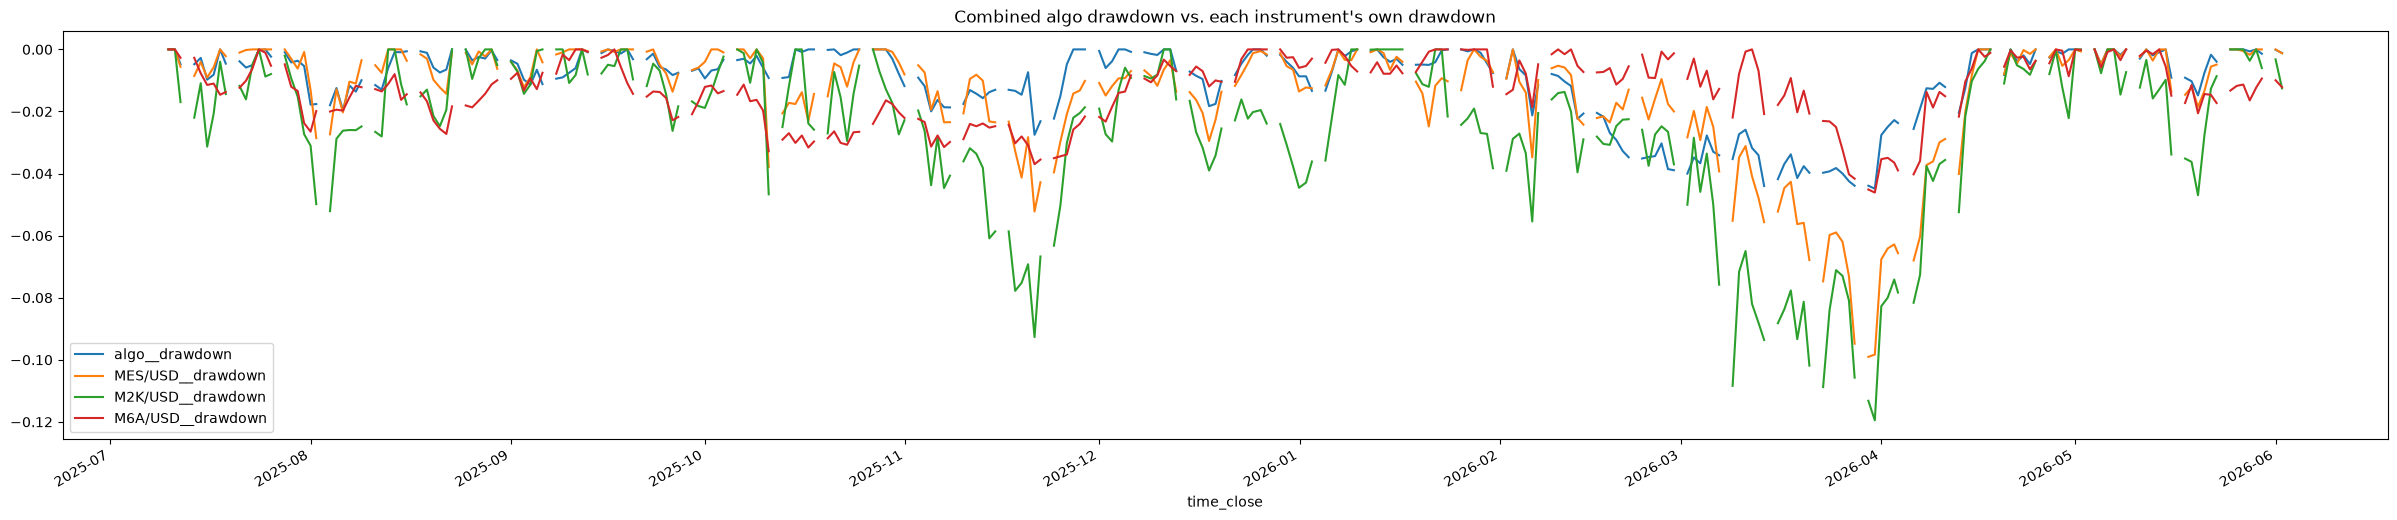

In [6]:

if backtest.reporter.merged is not None:
    y_cols = ["algo__cumulative_returns"] + [f"{sym}/USD__cumulative_returns" for sym in SELECTED_SYMBOLS]
    backtest.reporter.merged.plot(x="time_close", y=y_cols, figsize=(30, 6),
                                   title=f"Combined algo vs. each of {SELECTED_SYMBOLS}'s buy-and-hold")

    dd_cols = ["algo__drawdown"] + [f"{sym}/USD__drawdown" for sym in SELECTED_SYMBOLS]
    backtest.reporter.merged.plot(x="time_close", y=dd_cols, figsize=(30, 6),
                                   title="Combined algo drawdown vs. each instrument's own drawdown")


## Exposure / leverage -- confirms the "1 contract each" target actually held


Max effective leverage reached: 1.0672280448776075
Mean effective leverage while any position open: 0.6485448352958959

Per-symbol contract-count distribution (should hover at 0 or 1, rarely if ever 2+):


,M2K/USD__contracts,MES/USD__contracts,M6A/USD__contracts
count,5312.000000,5312.000000,5312.000000
mean,0.528238,0.562312,0.554782
std,0.499249,0.496149,0.497037
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


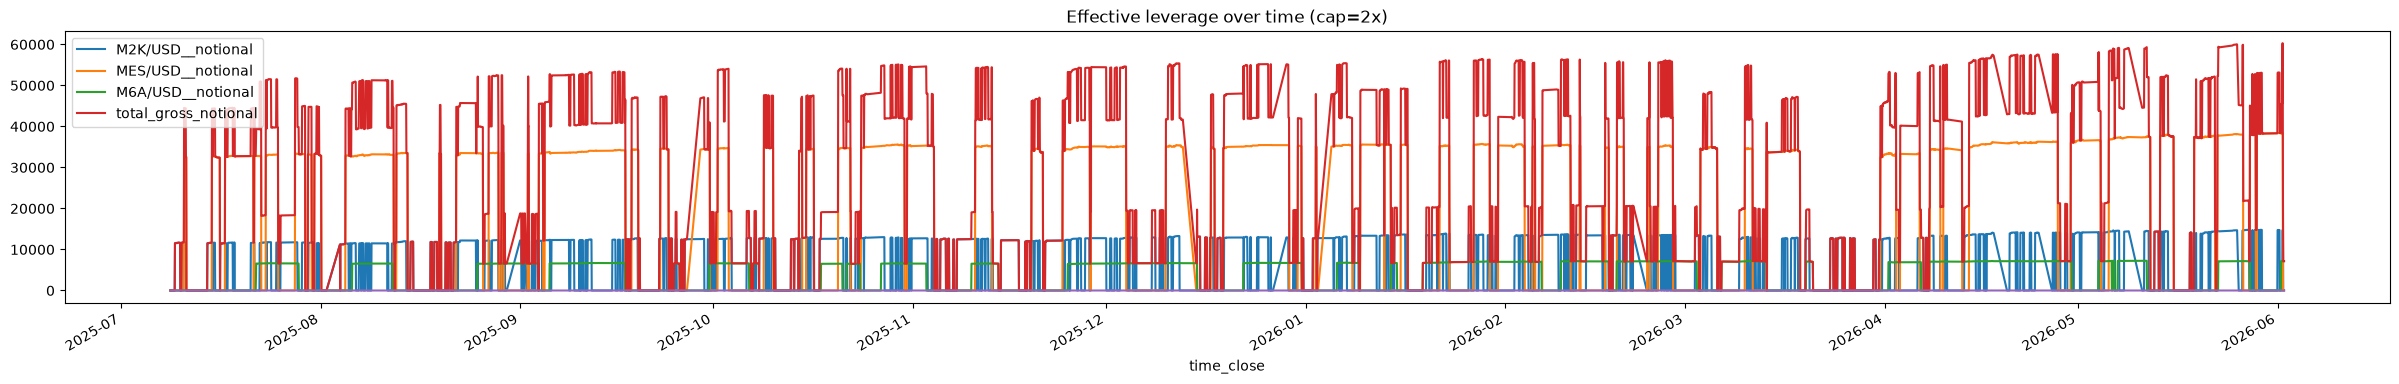

In [7]:

exposure_df = exposure_recorder.to_frame()
contract_cols = [c for c in exposure_df.columns if c.endswith("__contracts")]
notional_cols = [c for c in exposure_df.columns if c.endswith("__notional")]

exposure_df[notional_cols + ["total_gross_notional"]].plot(
    figsize=(30, 6), title="Per-symbol notional + total gross notional over time"
)
exposure_df["effective_leverage"].plot(
    figsize=(30, 4), title=f"Effective leverage over time (cap={MAX_LEVERAGE}x)"
)

print("Max effective leverage reached:", exposure_df["effective_leverage"].max())
print("Mean effective leverage while any position open:",
      exposure_df.loc[exposure_df['total_gross_notional'] > 0, 'effective_leverage'].mean())
print()
print("Per-symbol contract-count distribution (should hover at 0 or 1, rarely if ever 2+):")
exposure_df[contract_cols].describe()


In [8]:

def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

trades_df = pd.DataFrame([_trade_to_dict(t) for t in backtest.reporter.trades])
print(f"Total trades across {SELECTED_SYMBOLS}: {len(trades_df)}")
trades_df["symbol"].value_counts()


Total trades across ['MES', 'M2K', 'M6A']: 398


symbol
M2K/USD    306
MES/USD     66
M6A/USD     26
Name: count, dtype: int64

In [9]:
trades_df


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period,risk_percent
0,MES/USD,long,1752170399999000000,1752202799999000000,6545.5000,6515.0000,signal,-0.004660,loser,32400000000000,0.3
1,MES/USD,long,1752544799999000000,1752652799999000000,6540.0000,6482.5000,signal,-0.008792,loser,108000000000000,0.3
2,MES/USD,long,1752721199999000000,1753102799999000000,6501.5000,6555.7500,signal,0.008344,winner,381600000000000,0.3
3,MES/USD,long,1753113599999000000,1753207199999000000,6584.2500,6553.7500,signal,-0.004632,loser,93600000000000,0.3
4,MES/USD,long,1753268399999000000,1753433999999000000,6584.2500,6621.5000,signal,0.005657,winner,165600000000000,0.3
...,...,...,...,...,...,...,...,...,...,...,...
393,M6A/USD,long,1775595599999000000,1777510799999000000,0.6959,0.7105,signal,0.020980,winner,1915200000000000,0.3
394,M6A/USD,long,1777867199999000000,1778047199999000000,0.7196,0.7230,signal,0.004725,winner,180000000000000,0.3
395,M6A/USD,long,1778057999999000000,1778083199999000000,0.7244,0.7218,signal,-0.003589,loser,25200000000000,0.3
396,M6A/USD,long,1778126399999000000,1778518799999000000,0.7225,0.7234,signal,0.001246,winner,392400000000000,0.3


## Caveats

- **Hand-picked, not searched** -- the upside is interpretability and every included
  instrument having a genuine standalone edge; the downside is this notebook no
  longer explores whether some other 3-instrument combination might combine better
  than the sum of its parts (the previous 20-combination search's whole point, even
  though its own winner didn't hold up under stress). If a systematic search gets
  revisited, doing it only over instruments that already clear a standalone-edge bar
  (unlike 6J) would be a reasonable middle ground.
- **`MAX_LEVERAGE=2` and `PRICE_HEADROOM=1.05` are this notebook's own choices**, not
  independently validated -- they're picked to comfortably hold ~1 contract per
  instrument across this backtest's *observed* price range. `max_position_size=1` (see
  the `harness` cell) now hard-caps each instrument at 1 contract regardless of how
  much the account's equity compounds, so a strong run can no longer silently size up
  to 2 contracts -- but a large future price move well beyond this window's observed
  range could still floor a position to 0 contracts (the conservative failure mode,
  not the risky one).
- **`max_leverage=2` is still a stand-in**, not Tradovate's/Tradeify's real per-symbol
  margin schedule (not modeled anywhere in this system yet, see `PROP_FIRM_PLAN.md`).
- **Sharpe/Sortino/annualized-volatility now use `periods_per_year=252`** (real
  trading days/year for futures), not the `PerformanceAnalyzer` default of 365 (only
  correct for a 24/7 crypto market) -- the default was used throughout this pipeline
  until this pass, inflating every such figure by sqrt(365/252) =~ 1.20 (~20%).
  CAGR/Calmar/max_drawdown/net_return were never affected (they don't depend on
  `periods_per_year`).
- **Tradeify's real $1,250/day soft daily-loss pause is now modeled**
  (`MaxDailyLossMiddleware(max_loss_percent=0.025)`, 2.5% of a $50k account) --
  previously absent from every backtest in this pipeline despite being a documented
  real rule (`PROP_FIRM_PLAN.md`).
- Every individual instrument's own overfitting caveats (from their own `step_1`,
  ~1 year of data, single train/test holdout only) still apply here.
